# Two-Level: Sech Pulse 4π — Pulse Breakup

## Define the Problem

First we need to define a sech pulse with the area we want. We'll fix the width of the pulse and the area to find the right amplitude.

The full-width at half maximum (FWHM) $t_s$ of the sech pulse is related to the FWHM of a Gaussian by a factor of $1/2.6339157938$. (See §3.2.2 of my [PhD thesis](https://github.com/tommyogden/phd-thesis)).

In [1]:
import numpy as np

SECH_FWHM_CONV = 1.0 / 2.6339157938
t_width = 1.0 * SECH_FWHM_CONV  # [τ]
print("t_width", t_width)

t_width 0.3796628587572578


In [2]:
mb_solve_json = """
{
  "atom": {
    "fields": [
      {
        "coupled_levels": [[0, 1]],
        "rabi_freq_t_args": {
          "n_pi": 4.0,
          "centre": 0.0,
          "width": %f
        },
        "rabi_freq_t_func": "sech"
      }
    ],
    "num_states": 2
  },
  "t_min": -2.0,
  "t_max": 10.0,
  "t_steps": 240,
  "z_min": -0.5,
  "z_max": 1.5,
  "z_steps": 100,
  "interaction_strengths": [
    10.0
  ],
  "savefile": "mbs-two-sech-4pi"
}
""" % (t_width)

In [3]:
from maxwellbloch import mb_solve

mbs = mb_solve.MBSolve().from_json_str(mb_solve_json)

We'll just check that the pulse area is what we want.

In [4]:
print(
    "The input pulse area is {0}".format(
        np.trapezoid(mbs.Omegas_zt[0, 0, :].real, mbs.tlist) / np.pi
    )
)

The input pulse area is 3.986854595865458


In [17]:
Omegas_zt, states_zt = mbs.mbsolve(recalc=False)

## Plot Output

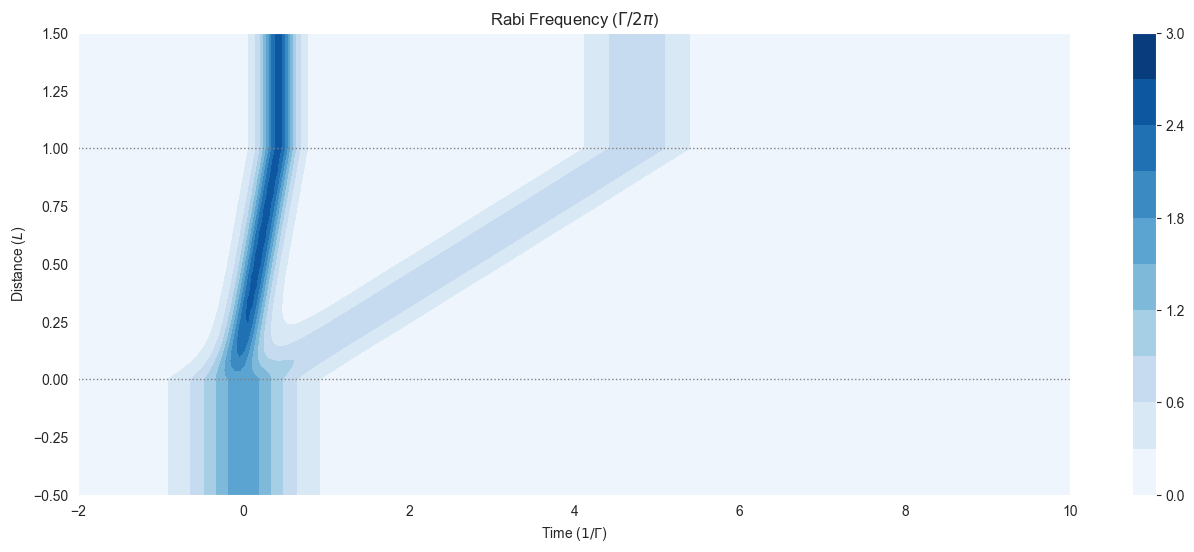

In [6]:
import matplotlib.pyplot as plt

%matplotlib inline
import seaborn as sns

sns.set_style("darkgrid")
fig = plt.figure(1, figsize=(16, 6))
ax = fig.add_subplot(111)
cmap_range = np.linspace(0.0, 3.0, 11)
cf = ax.contourf(
    mbs.tlist,
    mbs.zlist,
    np.abs(mbs.Omegas_zt[0] / (2 * np.pi)),
    cmap_range,
    cmap=plt.cm.Blues,
)
ax.set_title(r"Rabi Frequency ($\Gamma / 2\pi $)")
ax.set_xlabel(r"Time ($1/\Gamma$)")
ax.set_ylabel("Distance ($L$)")
for y in [0.0, 1.0]:
    ax.axhline(y, c="grey", lw=1.0, ls="dotted")
plt.colorbar(cf);

Text(0, 0.5, 'Pulse Area ($\\pi$)')

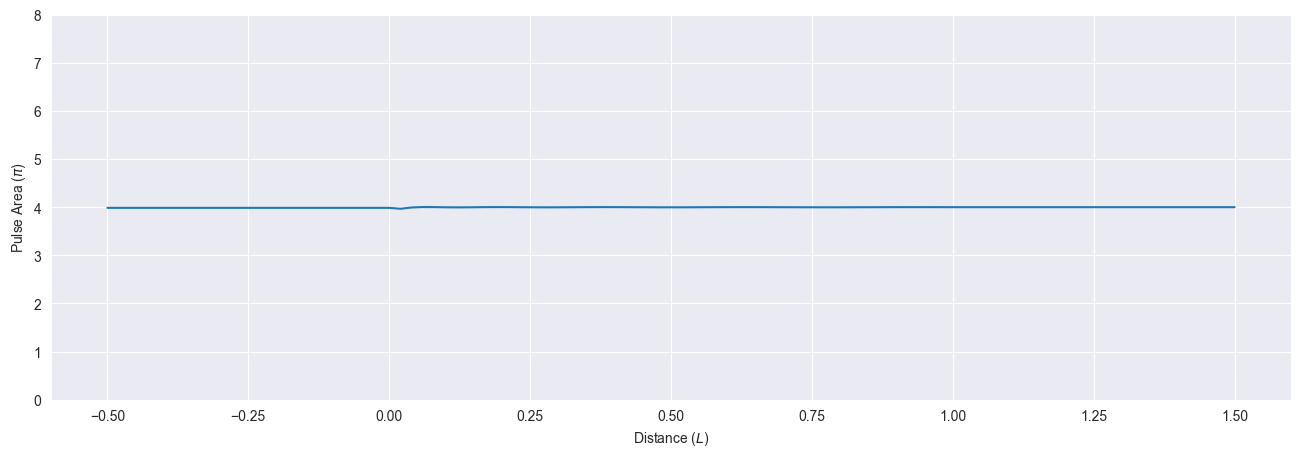

In [7]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(mbs.zlist, mbs.fields_area()[0] / np.pi)
ax.set_ylim([0.0, 8.0])
ax.set_xlabel("Distance ($L$)")
ax.set_ylabel(r"Pulse Area ($\pi$)")

## Analysis

The $4 \pi$ sech pulse breaks up into two $2 \pi$ pulses, which travel at a speed according to their width.

## Movie

In [8]:
# C = 0.1 # speed of light
# Y_MIN = 0.0 # Y-axis min
# Y_MAX = 4.0 # y-axis max
# ZOOM = 2 # level of linear interpolation
# FPS = 60 # frames per second
# ATOMS_ALPHA = 0.2 # Atom indicator transparency

In [9]:
# FNAME = "images/mb-solve-two-sech-4pi"
# FNAME_JSON = FNAME + '.json'
# with open(FNAME_JSON, "w") as f:
#     f.write(mb_solve_json)

In [10]:
# !make-mp4-fixed-frame.py -f $FNAME_JSON -c $C --fps $FPS --y-min $Y_MIN --y-max $Y_MAX \
#     --zoom $ZOOM --atoms-alpha $ATOMS_ALPHA #--peak-line --c-line

In [11]:
# FNAME_MP4 = FNAME + '.mp4'
# !make-gif-ffmpeg.sh -f $FNAME_MP4 --in-fps $FPS

In [12]:
# from IPython.display import Image
# Image(url=FNAME_MP4 +'.gif', format='gif')